# 🌍 Weather Data – First Step into Geo Intelligence

Every morning, before stepping outside, we check the weather on our phones.  

Will it rain? ☔ Is it hot? Do we need a jacket?

This simple daily habit reflects something powerful: **data drives decisions**.

This notebook marks the starting point of a broader journey into **Geo-Intelligence** — using location-based data to support smarter decisions.

Weather is our fun starting point and first layer of a **location intelligence framework**.


## 🛠️ Gathering libraries

In [ ]:
! pip install openmeteo-requests

In [ ]:
!pip install requests-cache retry-requests numpy pandas

In [ ]:
import openmeteo_requests
import requests
import pandas as pd
import requests_cache
from retry_requests import retry
from datetime import date, timedelta

### 🌍 Mozambique Adventure: Random Locations! 🗺️

For our simulation, we need **drop 📍** somewhere in Mozambique — but where exactly? Let’s let Python play explorer! 🕵️‍♂️✨

1. **Load Mozambique’s shape** from a GeoJSON map using its trusty ISO3 code `"MOZ"`. 🗺️  
2. **Draw a bounding box** — our explorer’s sandbox — covering all of Mozambique. 📦  
3. **Pick random points** inside the sandbox. 🎯  
4. **Check if the point is really in Mozambique** (no sneaky random neighbours allowed!) using rejection sampling. 🚫
5. **Return latitude & longitude** — the coordinates of our new “tower” or “store.” 📍  

Every point we generate is guaranteed to be **inside Mozambique**, ready for adventure… or, you know, for simulating traffic, revenue, and weather data! 🌦️💰

In [ ]:
import random
import json
import urllib.request
from shapely.geometry import shape, Point

def load_mozambique():
    """
    Loads Mozambique geometry from GeoJSON using ISO3166-1-Alpha-3 code "MOZ".
    """
    url = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
    with urllib.request.urlopen(url) as r:
        data = json.loads(r.read())

    for feature in data["features"]:
        props = feature.get("properties", {})
        if props.get("ISO3166-1-Alpha-3") == "MOZ":
            return shape(feature["geometry"])

    raise ValueError("Mozambique not found in GeoJSON")

# Load Mozambique polygon
MOZAMBIQUE = load_mozambique()

# Approximate bounding box for candidate points
BBOX = {"lat": (-26.9, -10.3), "lon": (30.2, 40.8)}

def get_random_location_mozambique() -> tuple:
    """
    Returns a random (latitude, longitude) strictly inside Mozambique using rejection sampling.
    """
    while True:
        lat = random.uniform(*BBOX["lat"])
        lon = random.uniform(*BBOX["lon"])
        point = Point(lon, lat)  # shapely expects (x=lon, y=lat)
        if MOZAMBIQUE.contains(point):
            return round(lat, 6), round(lon, 6)

# Example usage
lat, lon = get_random_location_mozambique()
print(f"Random Mozambique Location → Latitude: {lat}, Longitude: {lon}")

Random Mozambique Location → Latitude: -14.007674, Longitude: 36.519443


In [ ]:
from geopy.geocoders import Nominatim

# Initialize geocoder
geolocator = Nominatim(user_agent="telmoza_simulation")
# Reverse geocode
location = geolocator.reverse((lat, lon), exactly_one=True)
# Save as variable
nearest_place = location.address if location else "Unknown"

print(f"Random Mozambique Location → Latitude: {lat}, Longitude: {lon}")
print("Nearest place:", nearest_place)

Random Mozambique Location → Latitude: -14.007674, Longitude: 36.519443
Nearest place: Maua, Maúa, Niassa, Zona Norte, Moçambique


In [ ]:
# -------------------------------

# 1. Setup cache + retry session

# -------------------------------

cache_session = requests_cache.CachedSession(

    ".cache", expire_after=86400  # cache for 1 day

)

retry_session = retry(

    cache_session, retries=5, backoff_factor=0.2

)

openmeteo = openmeteo_requests.Client(session=retry_session)

In [ ]:
# -------------------------------
# Coordinates
# -------------------------------
LATITUDE = lat
LONGITUDE = lon

# -------------------------------
# Date range (last 30 days up to yesterday)
# -------------------------------
end_date = date.today() - timedelta(days=1)
start_date = end_date - timedelta(days=30)

# -------------------------------
# Open-Meteo archive request
# -------------------------------
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": start_date.isoformat(),
    "end_date": end_date.isoformat(),
    "daily": "precipitation_sum,temperature_2m_max,temperature_2m_min",
    "timezone": "UTC"
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

# -------------------------------
# Extract daily data
# -------------------------------
daily = response.Daily()
rainfall_mm = daily.Variables(0).ValuesAsNumpy()
temperature_max = daily.Variables(1).ValuesAsNumpy()
temperature_min = daily.Variables(2).ValuesAsNumpy()

dates = pd.date_range(
    start=pd.to_datetime(daily.Time(), unit="s", utc=True),
    periods=len(rainfall_mm),
    freq="D"
).date

# -------------------------------
# Create DataFrame
# -------------------------------
df = pd.DataFrame({
    "latitude": response.Latitude(),
    "longitude": response.Longitude(),
    "date": dates,
    "rainfall_mm": rainfall_mm,
    "temperature_2m_max": temperature_max,
    "temperature_2m_min": temperature_min
})

# -------------------------------
# Hot/Cold/Moderate temperature flag
# -------------------------------
def temp_category(max_temp):
    if max_temp < 20:
        return 0  # cold
    elif max_temp <= 30:
        return 1  # moderate
    else:
        return 2  # hot

df["temp_category"] = df["temperature_2m_max"].apply(temp_category)

# -------------------------------
# Rain flag
# -------------------------------
df["rain_flag"] = df["rainfall_mm"].apply(lambda x: 1 if x > 0 else 0)

# -------------------------------
# Extreme weather flag
# Example: rain > 10mm or temp > 35°C
# -------------------------------
df["extreme_flag"] = df.apply(
    lambda row: 1 if (row["rainfall_mm"] > 10 or row["temperature_2m_max"] > 35) else 0,
    axis=1
)

# -------------------------------
# Output
# -------------------------------
print("\nDaily Weather — ", nearest_place,"\n")


Daily Weather —  Maua, Maúa, Niassa, Zona Norte, Moçambique 



In [ ]:
import numpy as np

# -------------------------------
# Synthetic revenue generation
# -------------------------------
# Base revenue (in some currency units)
base_revenue = 1000

# Add variability: random noise + effect of weather
# Example assumptions:
# - Hot days might increase revenue slightly (+10%)
# - Rainy days might decrease revenue (-20%)
# - Random daily fluctuation
np.random.seed(42)  # for reproducibility

def generate_revenue(row):
    revenue = base_revenue
    # Effect of rain
    if row['rainfall_mm'] > 5:
        revenue *= 0.8  # decrease revenue on heavy rain
    # Effect of temperature
    if row['temperature_2m_max'] > 30:
        revenue *= 1.1  # increase revenue on hot days
    elif row['temperature_2m_max'] < 20:
        revenue *= 0.9  # decrease revenue on cold days
    # Add some random noise +/- 10%
    revenue *= np.random.uniform(0.9, 1.1)
    return round(revenue, 2)

# Apply to DataFrame
df['synthetic_revenue'] = df.apply(generate_revenue, axis=1)

# Preview
df

,latitude,longitude,date,rainfall_mm,temperature_2m_max,temperature_2m_min,temp_category,rain_flag,extreme_flag,synthetic_revenue
0,-14.024604,36.497696,2026-03-06,0.600000,29.549999,20.000000,1,1,0,974.91
1,-14.024604,36.497696,2026-03-07,2.200000,29.500000,19.650000,1,1,0,1090.14
2,-14.024604,36.497696,2026-03-08,4.400000,28.100000,19.450001,1,1,0,1046.40
3,-14.024604,36.497696,2026-03-09,15.900000,28.150000,19.100000,1,1,1,815.79
4,-14.024604,36.497696,2026-03-10,4.200000,28.000000,19.850000,1,1,0,931.20
5,-14.024604,36.497696,2026-03-11,5.000000,27.500000,20.049999,1,1,0,931.20
6,-14.024604,36.497696,2026-03-12,2.200000,28.750000,19.799999,1,1,0,911.62
7,-14.024604,36.497696,2026-03-13,29.699999,29.150000,20.000000,1,1,1,858.59
8,-14.024604,36.497696,2026-03-14,26.900002,27.400000,20.200001,1,1,1,816.18
9,-14.024604,36.497696,2026-03-15,27.100002,24.549999,20.250000,1,1,1,833.29


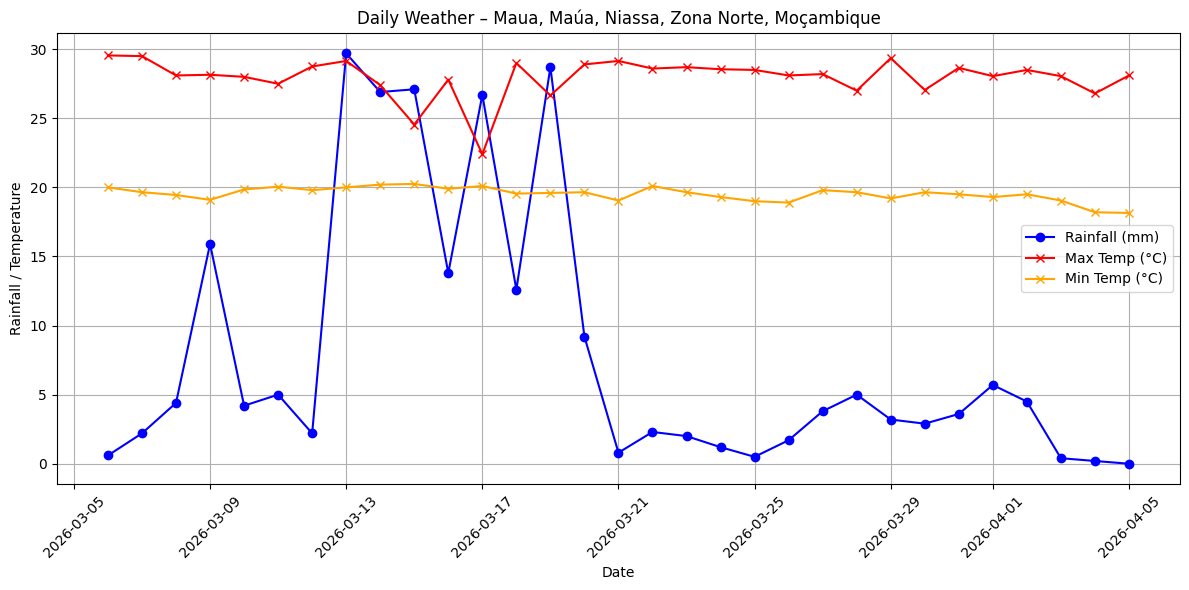

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['date'], df['rainfall_mm'], label='Rainfall (mm)', color='blue', marker='o')
plt.plot(df['date'], df['temperature_2m_max'], label='Max Temp (°C)', color='red', marker='x')
plt.plot(df['date'], df['temperature_2m_min'], label='Min Temp (°C)', color='orange', marker='x')
plt.title(f"Daily Weather – {nearest_place}")
plt.xlabel("Date")
plt.ylabel("Rainfall / Temperature")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

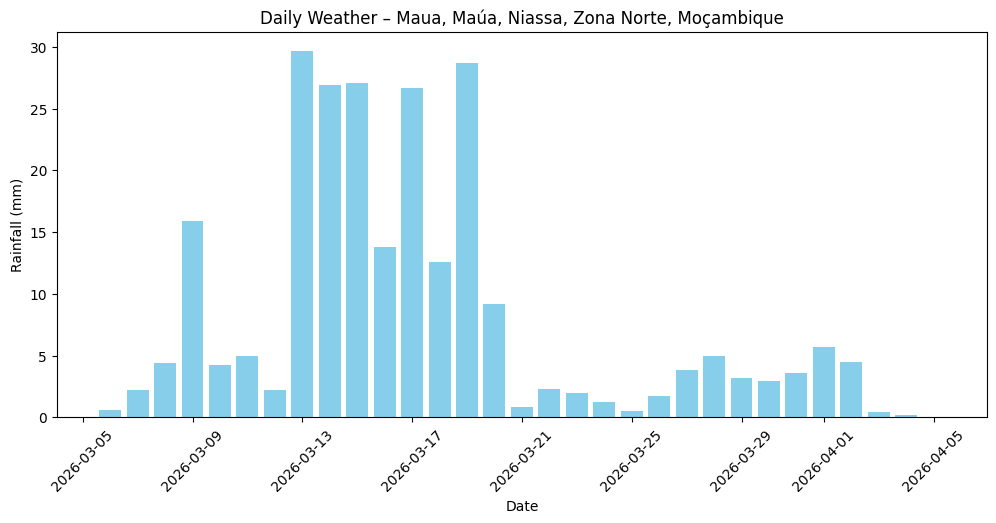

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(df['date'], df['rainfall_mm'], color='skyblue')
plt.title(f"Daily Weather – {nearest_place}")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=45)
plt.show()

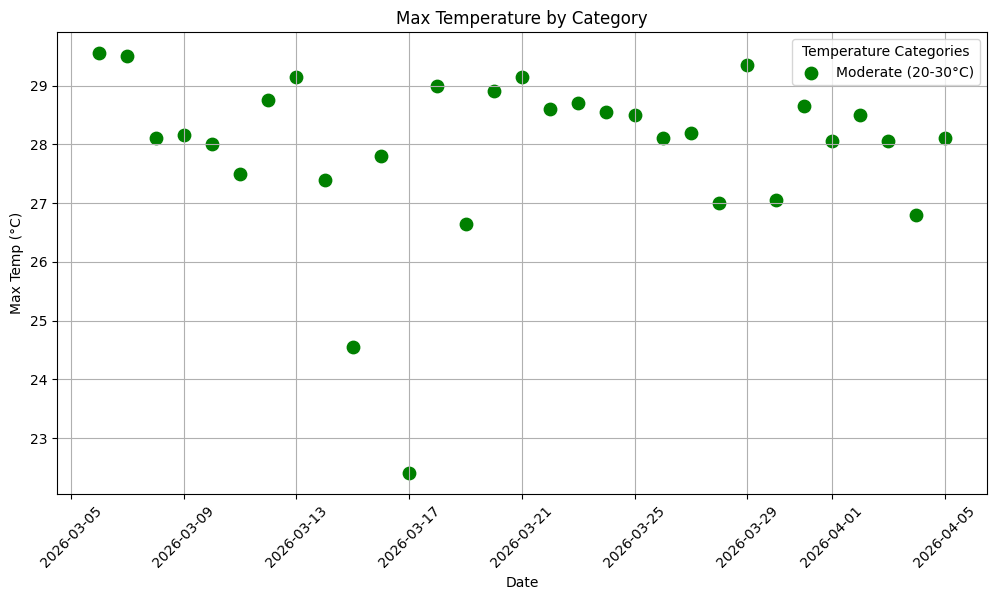

In [ ]:
# Mapping temperature category to color AND description
colors = {0:'blue', 1:'green', 2:'red'}
labels = {0:'Cold (<20°C)', 1:'Moderate (20-30°C)', 2:'Hot (>30°C)'}  # descriptive legend

plt.figure(figsize=(12,6))

for t in df['temp_category'].unique():
    subset = df[df['temp_category']==t]
    plt.scatter(subset['date'], subset['temperature_2m_max'],
                color=colors[t], label=labels[t], s=80)

plt.title("Max Temperature by Category")
plt.xlabel("Date")
plt.ylabel("Max Temp (°C)")
plt.xticks(rotation=45)
plt.legend(title="Temperature Categories")  # optional: add legend title
plt.grid(True)
plt.show()

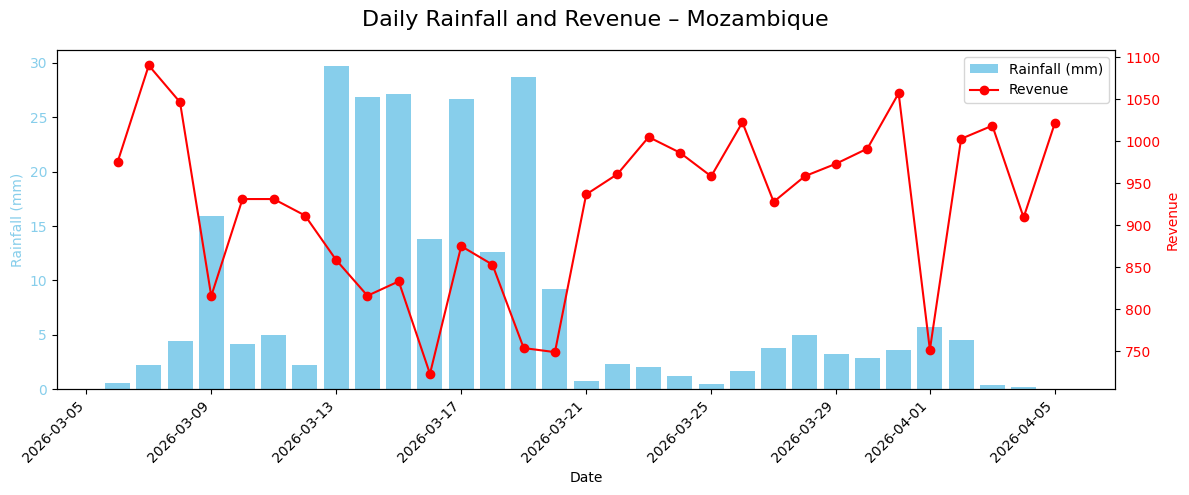

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,5))

# Bar chart for rainfall
ax1.bar(df['date'], df['rainfall_mm'], color='skyblue', label='Rainfall (mm)')
ax1.set_xlabel("Date")
ax1.set_ylabel("Rainfall (mm)", color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Rotate x-axis labels properly
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Line chart for revenue on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(df['date'], df['synthetic_revenue'], color='red', marker='o', label='Revenue')
ax2.set_ylabel("Revenue", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and combined legend
fig.suptitle("Daily Rainfall and Revenue – Mozambique", fontsize=16)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.show()